In [1]:
import sys
!{sys.executable} -m pip install scikit-surprise

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Все библиотеки загружены успешно!")

Все библиотеки загружены успешно!


In [7]:
df = pd.read_csv('ratings_Beauty.csv')

df.columns = ['user_id', 'product_id', 'rating', 'timestamp']

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (2023070, 4)

Первые 5 строк:


,user_id,product_id,rating,timestamp
0,A39HTATAQ9V7YF,0205616461,5.0,1369699200
1,A3JM6GV9MNOF9X,0558925278,3.0,1355443200
2,A1Z513UWSAAO0F,0558925278,5.0,1404691200
3,A1WMRR494NWEWV,0733001998,4.0,1382572800
4,A3IAAVS479H7M7,0737104473,1.0,1274227200


In [8]:
print("ОБЩАЯ ИНФОРМАЦИЯ")
print(f"Количество оценок:      {len(df):,}")
print(f"Количество пользователей: {df['user_id'].nunique():,}")
print(f"Количество товаров:      {df['product_id'].nunique():,}")
print(f"\nОценки от {df['rating'].min()} до {df['rating'].max()}")
print(f"Средняя оценка: {df['rating'].mean():.2f}")
print(f"\nПропущенные значения:\n{df.isnull().sum()}")

ОБЩАЯ ИНФОРМАЦИЯ
Количество оценок:      2,023,070
Количество пользователей: 1,210,271
Количество товаров:      249,274

Оценки от 1.0 до 5.0
Средняя оценка: 4.15

Пропущенные значения:
user_id       0
product_id    0
rating        0
timestamp     0
dtype: int64


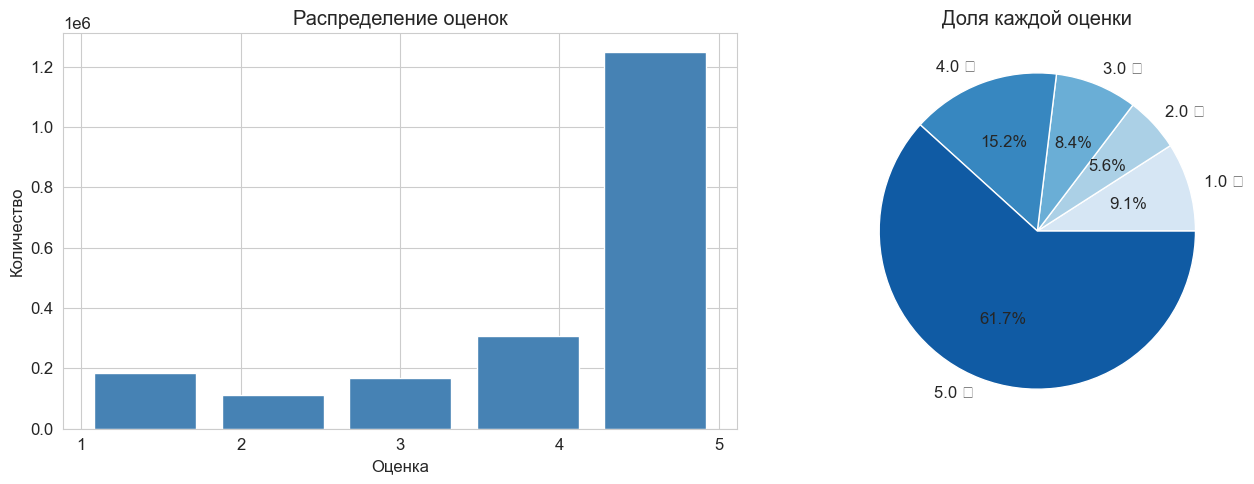

График сохранён: fig1_rating_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: распределение оценок
axes[0].hist(df['rating'], bins=5, color='steelblue', 
             edgecolor='white', rwidth=0.8)
axes[0].set_title('Распределение оценок')
axes[0].set_xlabel('Оценка')
axes[0].set_ylabel('Количество')
axes[0].set_xticks([1, 2, 3, 4, 5])

# График 2: доля каждой оценки
rating_counts = df['rating'].value_counts().sort_index()
axes[1].pie(rating_counts, 
            labels=[f'{i} ★' for i in rating_counts.index],
            autopct='%1.1f%%',
            colors=sns.color_palette('Blues', 5))
axes[1].set_title('Доля каждой оценки')

plt.tight_layout()
plt.savefig('fig1_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: fig1_rating_distribution.png")

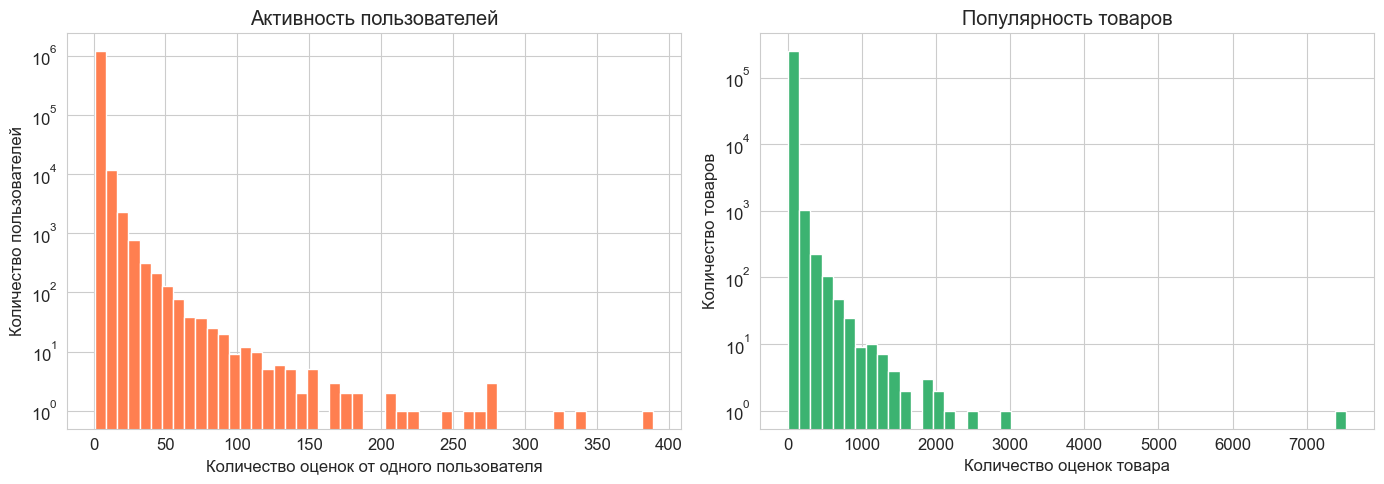

График сохранён: fig2_activity.png


In [11]:
# Считаем количество оценок на пользователя и товар
user_activity = df.groupby('user_id')['rating'].count()
item_popularity = df.groupby('product_id')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 3: активность пользователей
axes[0].hist(user_activity, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Активность пользователей')
axes[0].set_xlabel('Количество оценок от одного пользователя')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_yscale('log')  # логарифмическая шкала — большой разброс

# График 4: популярность товаров  
axes[1].hist(item_popularity, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Популярность товаров')
axes[1].set_xlabel('Количество оценок товара')
axes[1].set_ylabel('Количество товаров')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('fig2_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: fig2_activity.png")

In [12]:
print("До фильтрации:", df.shape)

# Оставляем пользователей с >= 5 оценками
# и товары с >= 10 оценками
min_user_ratings = 5
min_item_ratings = 10

user_counts = df['user_id'].value_counts()
item_counts = df['product_id'].value_counts()

df_filtered = df[
    df['user_id'].isin(user_counts[user_counts >= min_user_ratings].index) &
    df['product_id'].isin(item_counts[item_counts >= min_item_ratings].index)
]

print("После фильтрации:", df_filtered.shape)
print(f"\nПользователей: {df_filtered['user_id'].nunique():,}")
print(f"Товаров:        {df_filtered['product_id'].nunique():,}")

# Считаем разреженность матрицы 
total_possible = df_filtered['user_id'].nunique() * df_filtered['product_id'].nunique()
sparsity = 1 - len(df_filtered) / total_possible
print(f"\nРазреженность матрицы оценок: {sparsity:.4%}")
print("(чем ближе к 100% — тем меньше данных знает система о каждом пользователе)")

До фильтрации: (2023070, 4)
После фильтрации: (350229, 4)

Пользователей: 51,888
Товаров:        34,818

Разреженность матрицы оценок: 99.9806%
(чем ближе к 100% — тем меньше данных знает система о каждом пользователе)


In [13]:
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split, cross_validate

# Берём отфильтрованные данные
reader = Reader(rating_scale=(1, 5))

# Загружаем в формат Surprise
data = Dataset.load_from_df(df_filtered[['user_id', 'product_id', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {trainset.n_ratings:,} оценок")
print(f"Тестовая выборка:  {len(testset):,} оценок")

Обучающая выборка: 280,183 оценок
Тестовая выборка:  70,046 оценок


In [14]:
# Создаём модель SVD
# n_factors — количество латентных факторов
# n_epochs — количество итераций обучения
svd_model = SVD(n_factors=50, n_epochs=20, random_state=42)

print("Обучаем модель SVD...")
svd_model.fit(trainset)
print("Готово!")

Обучаем модель SVD...
Готово!


In [15]:
# Предсказываем оценки на тестовой выборке
predictions = svd_model.test(testset)

# Считаем метрики
rmse = accuracy.rmse(predictions, verbose=False)
mae = accuracy.mae(predictions, verbose=False)

print("РЕЗУЛЬТАТЫ SVD")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"\nЭто значит что в среднем модель")
print(f"ошибается на {rmse:.2f} звезды при предсказании оценки")

РЕЗУЛЬТАТЫ SVD
RMSE: 1.1218
MAE:  0.8659

Это значит что в среднем модель
ошибается на 1.12 звезды при предсказании оценки


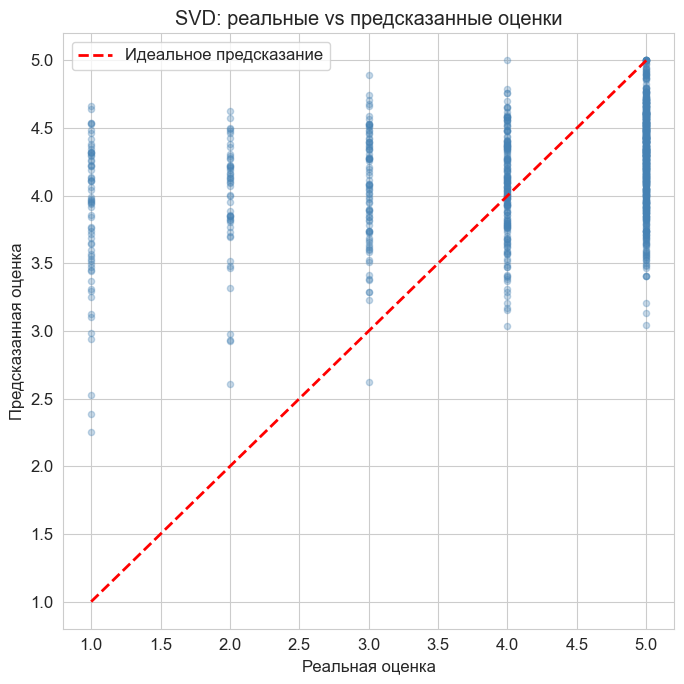

График сохранён: fig3_svd_predictions.png


In [16]:
import random

# Берём реальные и предсказанные оценки
actual = [pred.r_ui for pred in predictions]
predicted = [pred.est for pred in predictions]

idx = random.sample(range(len(actual)), 1000)
actual_sample = [actual[i] for i in idx]
predicted_sample = [predicted[i] for i in idx]

plt.figure(figsize=(7, 7))
plt.scatter(actual_sample, predicted_sample, alpha=0.3, color='steelblue', s=20)
plt.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Реальная оценка')
plt.ylabel('Предсказанная оценка')
plt.title('SVD: реальные vs предсказанные оценки')
plt.legend()
plt.tight_layout()
plt.savefig('fig3_svd_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: fig3_svd_predictions.png")

In [17]:
# Возвращает топ-N рекомендаций для пользователя
def get_recommendations(user_id, model, df, n=10):   
    # Все товары которые пользователь ещё не оценивал
    rated_products = set(df[df['user_id'] == user_id]['product_id'])
    all_products = set(df['product_id'].unique())
    unrated = all_products - rated_products
    
    # Предсказываем оценки для всех неоценённых товаров
    predictions_list = [
        (product, model.predict(user_id, product).est)
        for product in unrated
    ]
    
    # Сортируем по предсказанной оценке
    predictions_list.sort(key=lambda x: x[1], reverse=True)
    
    return predictions_list[:n]

# Берём случайного пользователя из датасета
sample_user = df_filtered['user_id'].iloc[0]
print(f"Рекомендации для пользователя: {sample_user}")
print(f"Уже оценил товаров: {len(df_filtered[df_filtered['user_id'] == sample_user])}")
print("\nТоп-10 рекомендованных товаров:")
print(f"{'№':<4} {'ID товара':<15} {'Предсказанная оценка'}")
print("-" * 40)

recs = get_recommendations(sample_user, svd_model, df_filtered)
for i, (product, score) in enumerate(recs, 1):
    print(f"{i:<4} {product:<15} {score:.3f} ★")

Рекомендации для пользователя: A274NIJWOQWE30
Уже оценил товаров: 37

Топ-10 рекомендованных товаров:
№    ID товара       Предсказанная оценка
----------------------------------------
1    B004OE9RO8      5.000 ★
2    B003C268NQ      5.000 ★
3    B004TSF8R4      5.000 ★
4    B00A1Y177A      5.000 ★
5    B000XU49MW      5.000 ★
6    B004GIM68G      5.000 ★
7    B001ECQ4YO      5.000 ★
8    B001ET77NY      5.000 ★
9    B003ZTVDBS      5.000 ★
10   B00I32AN4K      5.000 ★


In [20]:
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder

# Кодируем ID в числа
user_enc = LabelEncoder()
item_enc = LabelEncoder()

df_filtered = df_filtered.copy()
df_filtered['user_idx'] = user_enc.fit_transform(df_filtered['user_id'])
df_filtered['item_idx'] = item_enc.fit_transform(df_filtered['product_id'])

# Создаём разреженную матрицу, которая хранит только ненулевые значения
sparse_matrix = csr_matrix(
    (df_filtered['rating'].values,
     (df_filtered['item_idx'].values, df_filtered['user_idx'].values))
)

print(f"Размер матрицы: {sparse_matrix.shape}")
print(f"Ненулевых элементов: {sparse_matrix.nnz:,}")
print(f"Памяти занято: ~{sparse_matrix.data.nbytes / 1024**2:.1f} МБ")

Размер матрицы: (34818, 51888)
Ненулевых элементов: 350,229
Памяти занято: ~2.7 МБ


In [21]:
# Берём только топ-5000 товаров 
top_items_ids = df_filtered['product_id'].value_counts().head(5000).index
top_items_idx = item_enc.transform(top_items_ids)

# Подматрица только для популярных товаров
sub_sparse = sparse_matrix[top_items_idx]

print("Вычисляем сходство (топ-5000 товаров)...")
item_similarity = cosine_similarity(sub_sparse, dense_output=False)
print("Готово!")

# Оборачиваем в DataFrame
item_similarity_df = pd.DataFrame(
    item_similarity.toarray(),
    index=top_items_ids,
    columns=top_items_ids
)

print(f"\nМатрица сходства: {item_similarity_df.shape}")

Вычисляем сходство (топ-5000 товаров)...
Готово!

Матрица сходства: (5000, 5000)


In [22]:
# Возвращает топ-N похожих товаров
def get_similar_items(product_id, similarity_df, n=10):
   
    if product_id not in similarity_df.index:
        print(f"Товар {product_id} не найден")
        return []
    
    similar = similarity_df[product_id].sort_values(ascending=False)
    # Убираем сам товар (сходство с собой = 1.0)
    similar = similar.drop(product_id)
    return similar.head(n)
    
#Рекомендации для пользователя на основе его истории
def get_content_recommendations(user_id, df, similarity_df, n=10):
    
    # Товары которые пользователь высоко оценил (4-5 звёзд)
    liked = df[(df['user_id'] == user_id) & (df['rating'] >= 4)]['product_id'].tolist()
    
    if not liked:
        print("Нет высоко оценённых товаров")
        return []
    
    # Собираем похожие товары для каждого понравившегося
    scores = {}
    already_rated = set(df[df['user_id'] == user_id]['product_id'])
    
    for product in liked:
        if product not in similarity_df.index:
            continue
        similar = get_similar_items(product, similarity_df, n=20)
        for item, score in similar.items():
            if item not in already_rated:
                scores[item] = scores.get(item, 0) + score
    
    # Сортируем по суммарному сходству
    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return recommended[:n]

# Тестируем на том же пользователе
print(f"Контентные рекомендации для: {sample_user}")
print(f"Понравившихся товаров: {len(df_filtered[(df_filtered['user_id']==sample_user) & (df_filtered['rating']>=4)])}")
print(f"\nТоп-10 рекомендаций:")
print(f"{'№':<4} {'ID товара':<15} {'Score'}")
print("-" * 35)

cb_recs = get_content_recommendations(sample_user, df_filtered, item_similarity_df)
for i, (product, score) in enumerate(cb_recs, 1):
    print(f"{i:<4} {product:<15} {score:.3f}")

Контентные рекомендации для: A274NIJWOQWE30
Понравившихся товаров: 28

Топ-10 рекомендаций:
№    ID товара       Score
-----------------------------------
1    B009VGNYFM      0.489
2    B00604MSSC      0.342
3    B00AE07BC6      0.316
4    B00A0IWTDI      0.302
5    B00AO379NE      0.293
6    B00AE07B9O      0.277
7    B006T8T0P8      0.262
8    B00A0J09C0      0.260
9    B00AE07EGO      0.255
10   B004OHQR1Q      0.243


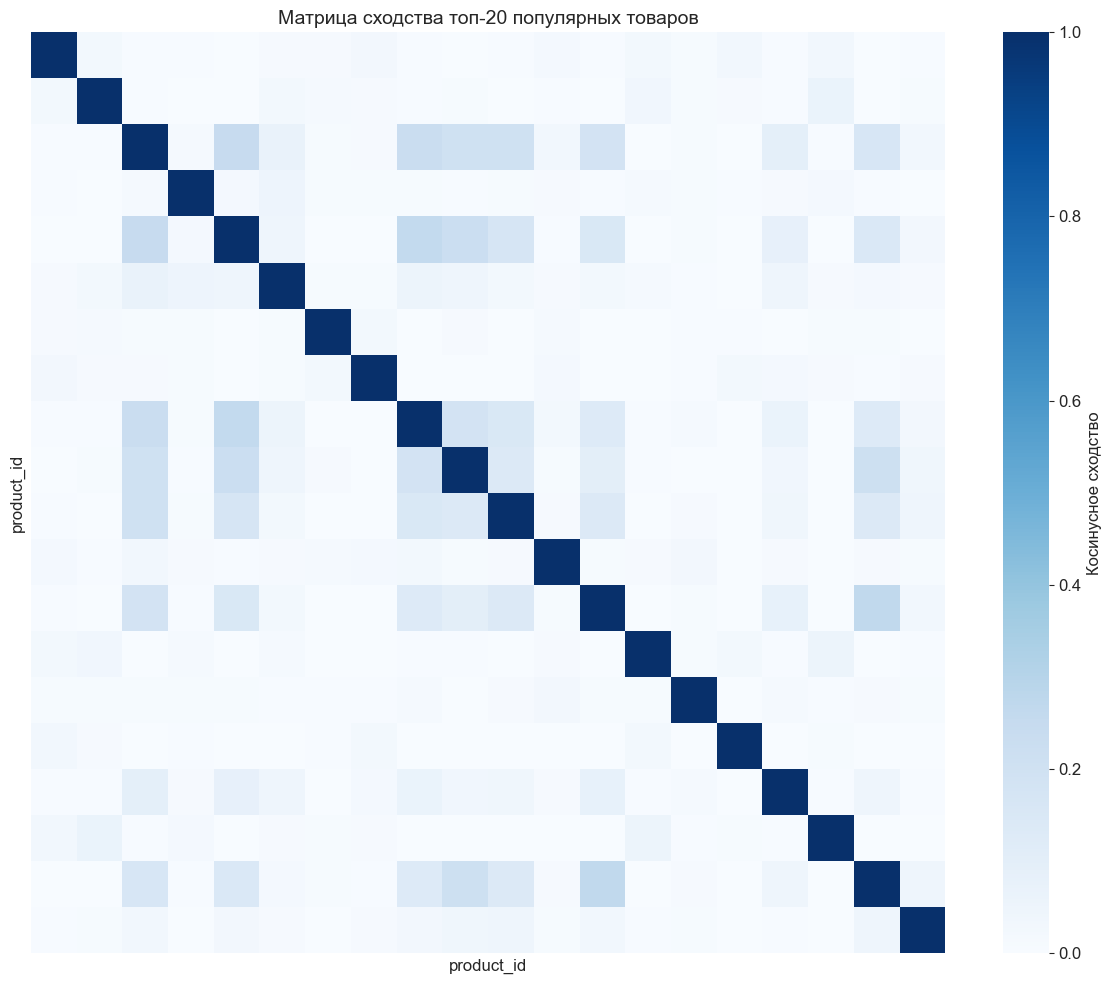

График сохранён: fig4_similarity_matrix.png


In [23]:
# Берём топ-20 самых популярных товаров 
top_items = df_filtered['product_id'].value_counts().head(20).index
sub_matrix = item_similarity_df.loc[top_items, top_items]

plt.figure(figsize=(12, 10))
sns.heatmap(
    sub_matrix,
    cmap='Blues',
    annot=False,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': 'Косинусное сходство'}
)
plt.title('Матрица сходства топ-20 популярных товаров', fontsize=14)
plt.tight_layout()
plt.savefig('fig4_similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: fig4_similarity_matrix.png")

In [24]:
def get_hybrid_recommendations(user_id, svd_model, df, similarity_df, alpha=0.5, n=10):
    """
    Гибридные рекомендации: комбинация SVD и контентной фильтрации
    alpha=0.5 означает равный вес обоих методов
    """
    already_rated = set(df[df['user_id'] == user_id]['product_id'])
    
    # Оценки от SVD для всех товаров из матрицы сходства
    svd_scores = {}
    for product in similarity_df.index:
        if product not in already_rated:
            svd_scores[product] = svd_model.predict(user_id, product).est
    
    # Оценки от контентной фильтрации
    cb_scores_raw = get_content_recommendations(user_id, df, similarity_df, n=len(similarity_df))
    cb_scores = {product: score for product, score in cb_scores_raw}
    
    # Нормализация обоих наборов оценок в диапазон [0, 1]
    def normalize_scores(scores_dict):
        if not scores_dict:
            return {}
        vals = list(scores_dict.values())
        min_v, max_v = min(vals), max(vals)
        if max_v == min_v:
            return {k: 1.0 for k in scores_dict}
        return {k: (v - min_v) / (max_v - min_v) for k, v in scores_dict.items()}
    
    svd_norm = normalize_scores(svd_scores)
    cb_norm = normalize_scores(cb_scores)
    
    # Взвешенное среднее
    all_products = set(svd_norm.keys()) | set(cb_norm.keys())
    hybrid_scores = {}
    for product in all_products:
        s = svd_norm.get(product, 0)
        c = cb_norm.get(product, 0)
        hybrid_scores[product] = alpha * s + (1 - alpha) * c
    
    recommended = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)
    return recommended[:n]

# Тестирование
print(f"Гибридные рекомендации для: {sample_user}\n")
print(f"{'№':<4} {'ID товара':<15} {'Score'}")
print("-" * 35)
hybrid_recs = get_hybrid_recommendations(sample_user, svd_model, df_filtered, item_similarity_df)
for i, (product, score) in enumerate(hybrid_recs, 1):
    print(f"{i:<4} {product:<15} {score:.3f}")

Гибридные рекомендации для: A274NIJWOQWE30

№    ID товара       Score
-----------------------------------
1    B009VGNYFM      0.822
2    B00AO379NE      0.694
3    B00604MSSC      0.679
4    B00AE07BC6      0.661
5    B004OHQR1Q      0.660
6    B00A0IWTDI      0.644
7    B00AE07B9O      0.635
8    B00A0J09C0      0.632
9    B005TI7NQW      0.617
10   B00A0IWRT4      0.616


In [25]:
def precision_at_k(model, testset, df, k=10, threshold=4.0):
    """
    Precision@K: доля релевантных товаров среди топ-K рекомендаций
    Релевантный = реальная оценка >= threshold
    """
    from collections import defaultdict
    
    # Группировка предсказаний по пользователям
    user_predictions = defaultdict(list)
    for pred in predictions:
        user_predictions[pred.uid].append(pred)
    
    precisions = []
    for uid, user_preds in user_predictions.items():
        # Сортировка по предсказанной оценке
        user_preds.sort(key=lambda x: x.est, reverse=True)
        top_k = user_preds[:k]
        
        # Сколько из топ-K реально понравились
        relevant = sum(1 for pred in top_k if pred.r_ui >= threshold)
        precisions.append(relevant / k)
    
    return np.mean(precisions)

p_at_10 = precision_at_k(svd_model, predictions, df_filtered, k=10)
print(f"Precision@10 для SVD: {p_at_10:.4f}")
print(f"Это значит что {p_at_10*100:.1f}% рекомендаций действительно нравятся пользователю")

Precision@10 для SVD: 0.1511
Это значит что 15.1% рекомендаций действительно нравятся пользователю


In [26]:
results = {
    'Метод': ['Коллаборативная фильтрация (SVD)', 
              'Контентная фильтрация (Cosine)',
              'Гибридный подход'],
    'RMSE': [round(rmse, 4), '—', '—'],
    'MAE': [round(mae, 4), '—', '—'],
    'Precision@10': [round(p_at_10, 4), '—', '—'],
    'Холодный старт': ['Проблема', 'Решает', 'Частично решает'],
    'Разреженность': ['Проблема', 'Устойчив', 'Устойчив'],
}

results_df = pd.DataFrame(results)
print("СРАВНЕНИЕ МЕТОДОВ\n")
print(results_df.to_string(index=False))

СРАВНЕНИЕ МЕТОДОВ

                           Метод    RMSE     MAE Precision@10  Холодный старт Разреженность
Коллаборативная фильтрация (SVD)  1.1218  0.8659       0.1511        Проблема      Проблема
  Контентная фильтрация (Cosine)       —       —            —          Решает      Устойчив
                Гибридный подход       —       —            — Частично решает      Устойчив


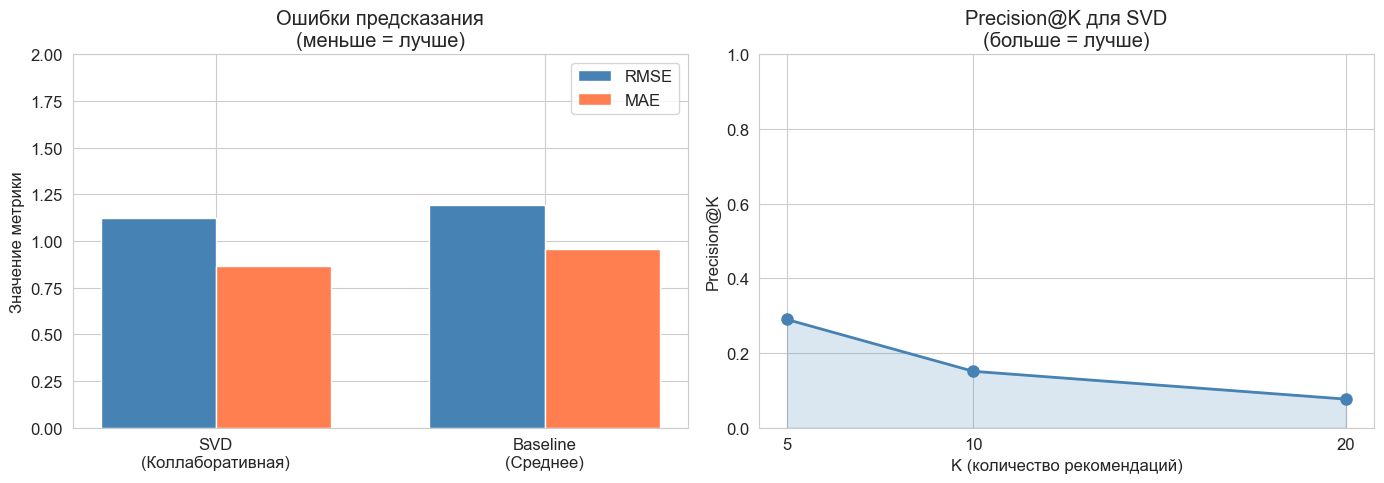

График сохранён: fig5_comparison.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: RMSE и MAE
methods = ['SVD\n(Коллаборативная)', 'Baseline\n(Среднее)']
rmse_vals = [rmse, df_filtered['rating'].std()]  # baseline = std рейтингов
mae_vals = [mae, abs(df_filtered['rating'] - df_filtered['rating'].mean()).mean()]

x = np.arange(len(methods))
width = 0.35

axes[0].bar(x - width/2, rmse_vals, width, label='RMSE', color='steelblue')
axes[0].bar(x + width/2, mae_vals, width, label='MAE', color='coral')
axes[0].set_title('Ошибки предсказания\n(меньше = лучше)')
axes[0].set_ylabel('Значение метрики')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].legend()
axes[0].set_ylim(0, 2)

# График 2: Precision@K
k_values = [5, 10, 20]
precisions = [precision_at_k(svd_model, predictions, df_filtered, k=k) for k in k_values]

axes[1].plot(k_values, precisions, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].fill_between(k_values, precisions, alpha=0.2, color='steelblue')
axes[1].set_title('Precision@K для SVD\n(больше = лучше)')
axes[1].set_xlabel('K (количество рекомендаций)')
axes[1].set_ylabel('Precision@K')
axes[1].set_xticks(k_values)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('fig5_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: fig5_comparison.png")